In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv("src/data/lenguaspaises.csv")

### Análisis univariante: grado de peligro de extinción

mean      2.609253
median    2.000000
std       1.288136
min       1.000000
max       5.000000
Name: endangerment_score, dtype: float64


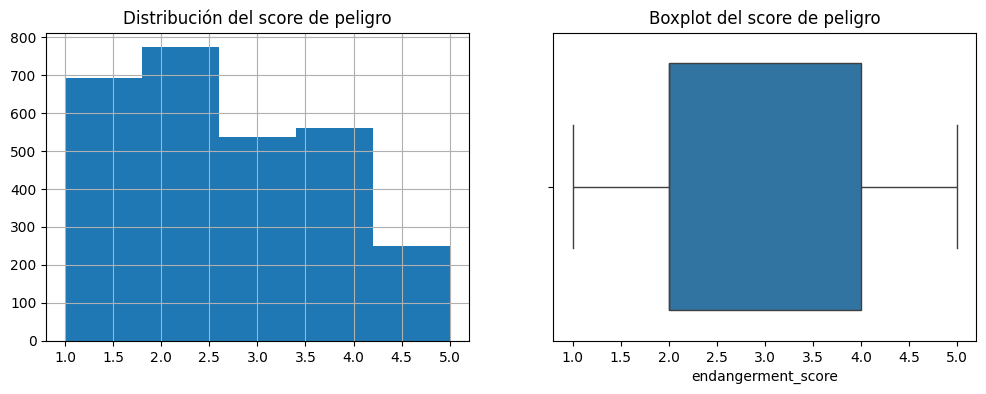

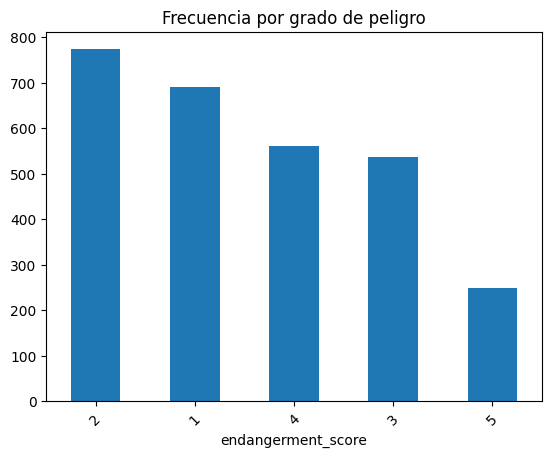

In [53]:
# Estadísticos de centralidad y dispersión
stats = df['endangerment_score'].agg(['mean', 'median', 'std', 'min', 'max'])
print(stats)

# Histograma + boxplot de endangerment_score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['endangerment_score'].hist(bins=5, ax=axes[0])
axes[0].set_title('Distribución del score de peligro')
sns.boxplot(x=df['endangerment_score'], ax=axes[1])
axes[1].set_title('Boxplot del score de peligro')
plt.show()

# Variable categórica: grado de peligro
df['endangerment_score'].value_counts().plot(kind='bar')
plt.title('Frecuencia por grado de peligro')
plt.xticks(rotation=45)
plt.show()

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    2810 non-null   int64  
 1   Name_English          2810 non-null   str    
 2   Countries             2810 non-null   str    
 3   Degree_endangerment   2810 non-null   str    
 4   Number_speakers       2810 non-null   float64
 5   Description_location  1998 non-null   str    
 6   endangerment_score    2810 non-null   int64  
 7   Countries_list        2810 non-null   str    
 8   Region                2801 non-null   str    
 9   Population            2801 non-null   float64
 10  Area_sq_mi            2801 non-null   float64
 11  Pop_density           2801 non-null   float64
 12  Coastline             2801 non-null   float64
 13  Migration             2801 non-null   float64
 14  Infant_mortality      2801 non-null   float64
 15  GDP                   2801 non-n

In [9]:
print(df.columns.tolist())

['ID', 'Name_English', 'Countries', 'Degree_endangerment', 'Number_speakers', 'Description_location', 'endangerment_score', 'Countries_list', 'Region', 'Population', 'Area_sq_mi', 'Pop_density', 'Coastline', 'Migration', 'Infant_mortality', 'GDP', 'Literacy', 'Phones', 'Arable', 'Crops', 'Other', 'Climate', 'Birthrate', 'Deathrate', 'Agriculture', 'Industry', 'Service']


# H3: PIB per cápita y extinción lingüística
Hipótesis: **Los países con mayor PIB per cápita tienen, de media, lenguas con menor grado de peligro: el desarrollo económico se asocia con mayor preservación lingüística.**  
Evaluaremos esta hipótesis con el **coeficiente de correlación de Spearman** ya que mide la relación monótona entre dos variables sin exigir normalidad, sin asumir linealidad y funciona con variables ordinales como nuestro `endangerment_score`. El PIB per cápita también presenta una distribución muy sesgada con outliers extremos, lo que hace que Pearson no sea adecuado.  
*Evaluación de los resultados*:
- Si al aumentar el PIB per cápita el score de peligro tiende a disminuir, ρ será negativo → el desarrollo económico protege las lenguas.
- Si ambas variables crecen juntas, ρ será positivo → el desarrollo económico no frena la extinción.
- Si no hay patrón monótono, ρ estará cerca de 0 → el PIB no explica el grado de peligro.

In [12]:
# DF con columnas necesarias - nulos
df_h3 = df[['GDP', 'endangerment_score']].dropna()

# Check de que GDP tiene valores numéricos; sustituir las comas x puntos
df_h3['GDP'] = (
    df_h3['GDP']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

print(f"filas válidas para la H3: {len(df_h3)}")
df_h3.describe()

filas válidas para la H3: 2801


,GDP,endangerment_score
count,2801.000000,2801.000000
mean,9934.044984,2.608354
std,11348.916674,1.288045
min,500.000000,1.000000
25%,2500.000000,2.000000
50%,5000.000000,2.000000
75%,9000.000000,4.000000
max,55100.000000,5.000000


In [16]:
from scipy.stats import spearmanr

corr, p_valor = spearmanr(df_h3['GDP'], df_h3['endangerment_score'])

print(f"Coeficiente de Spearman: {corr:.4f}")
print(f"p-valor:                 {p_valor:.4f}")

if p_valor < 0.05:
    direction = "negativa" if corr < 0 else "positiva"
    
    if abs(corr) < 0.1:
        fuerza = "prácticamente inexistente"
    elif abs(corr) < 0.3:
        fuerza = "débil"
    elif abs(corr) < 0.5:
        fuerza = "moderada"
    else:
        fuerza = "fuerte"
    
    print(f"→ Correlación {direction} (podríamos rechazar H0)")
    print(f"→ Fuerza del efecto: {fuerza} (ρ = {corr:.3f})")
else:
    print("→ No hay evidencia suficiente para rechazar H0")

Coeficiente de Spearman: 0.0710
p-valor:                 0.0002
→ Correlación positiva (podríamos rechazar H0)
→ Fuerza del efecto: prácticamente inexistente (ρ = 0.071)


## Resultados e interpretación
Spearman rho: 0.071 | p-value: 0.0002

El valor de la correlación de Spearman (0.071) indica una relación 
positiva prácticamente inexistente entre el PIB per cápita de un país 
y el nivel de peligro de sus lenguas.

Aunque el p-value (0.0002) confirma que la relación es estadísticamente 
significativa, esto se debe al gran tamaño muestral (n = 2.801): con tantos 
datos, el test detecta hasta las relaciones más pequeñas como significativas. 
El efecto real es despreciable y no permite afirmar que el desarrollo económico 
proteja las lenguas de su extinción. H3 se rechaza.

## H3. VISUALIZACIÓN
La relación entre el PIB per cápita y el grado de peligro de las lenguas 
se visualiza mediante un boxplot dividido en cuartiles de PIB. 
Las cajas muestran distribuciones muy similares entre los cuatro grupos, 
lo que confirma visualmente la correlación prácticamente inexistente 
observada en el análisis de Spearman.

C:\Users\User\AppData\Local\Temp\ipykernel_13148\2621954710.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


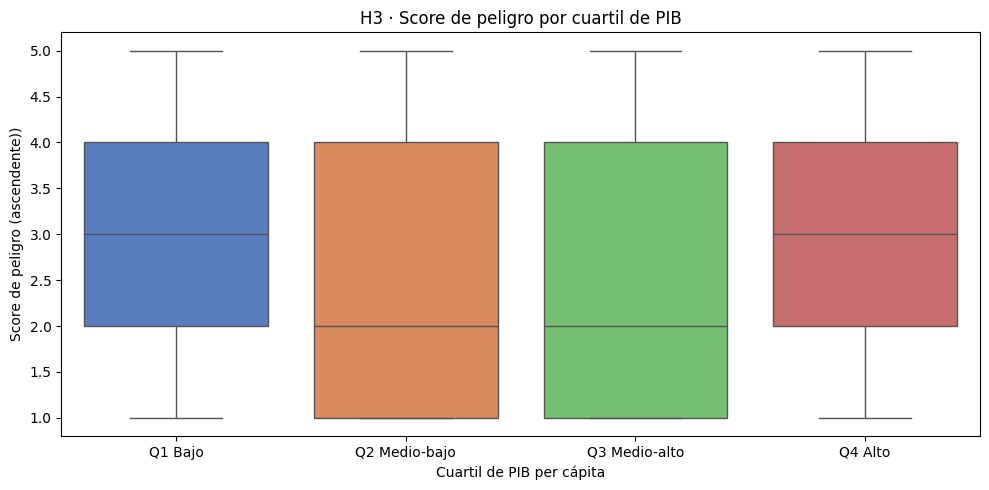

In [27]:
# dividimos la columna GDP en 4 grupos iguales (cuartiles), para facilitar la visualización
# y los etiquetamos con un grupo descriptivo consecuente 
df_h3['gdp_cuartil'] = pd.qcut(                                         # función para los cuartiles
    df_h3['GDP'],                                                       # columna a dividir en cuartiles
    q=4,                                                                # número de grupos
    labels=['Q1 Bajo', 'Q2 Medio-bajo', 'Q3 Medio-alto', 'Q4 Alto']     # las etiquetas
)

# creación del lienzo para el gráfico 10x5
fig, ax = plt.subplots(figsize=(10, 5))

# boxplot: eje X = cuartil de PIB, eje Y = score de peligro de extinción
sns.boxplot(
    data=df_h3,                                                         # dataframe con los datos
    x='gdp_cuartil',                                                    # grupos en el eje horizontal (X) con los cuartiles
    y='endangerment_score',                                             # valores en el eje vertical (Y) con el score
    palette='muted',                                                    # paleta de colores suaves
    ax=ax                                                               # lienzo creado
)

# etiquetas de los ejes y título 
ax.set_xlabel('Cuartil de PIB per cápita')
ax.set_ylabel('Score de peligro (ascendente))')
ax.set_title('H3 · Score de peligro por cuartil de PIB')

plt.tight_layout()                                                      # ajusta márgenes para que no se corten etiquetas
plt.savefig("src/img/H3-1.png")                                         # save en src/ img como png
plt.show()                                                              # muestra el gráfico

Como complemento, el scatterplot con la línea de tendencia muestra   
la relación de forma continua. La línea prácticamente plana confirma   
que no existe una tendencia clara entre el PIB per cápita de un país   
y el nivel de peligro de sus lenguas.

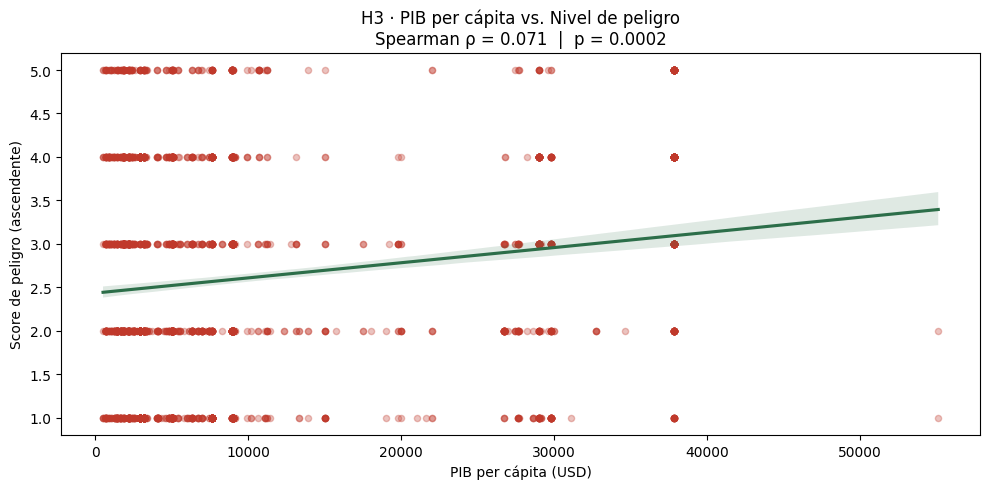

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.regplot(
    data=df_h3,
    x='GDP',
    y='endangerment_score',
    scatter_kws={'alpha': 0.3, 's': 20, 'color': '#c0392b'},
    line_kws={'color': '#2c6e49'},
    ax=ax
)

ax.set_xlabel('PIB per cápita (USD)')
ax.set_ylabel('Score de peligro (ascendente)')
ax.set_title(
    f'H3 · PIB per cápita vs. Nivel de peligro\nSpearman ρ = {corr:.3f}  |  p = {p_valor:.4f}',
    fontsize=12
)

plt.tight_layout()
plt.savefig("src/img/H3-2.png")                                         # save en src/ img como png
plt.show()

In [38]:
from scipy.stats import kruskal, shapiro, f_oneway

# dividimos la columna GDP en 4 grupos iguales (cuartiles), de nuevo
# y los etiquetamos con un grupo descriptivo consecuente 
df_h3['gdp_cuartil'] = pd.qcut(
    df_h3['GDP'],
    q=4,
    labels=['Q1 Bajo', 'Q2 Medio-bajo', 'Q3 Medio-alto', 'Q4 Alto']
)

grupos = [
    df_h3[df_h3['gdp_cuartil'] == cat]['endangerment_score'].values
    for cat in ['Q1 Bajo', 'Q2 Medio-bajo', 'Q3 Medio-alto', 'Q4 Alto']
]

# Verificar normalidad en cada grupo **(Shapiro-Wilk)**
print("Test de normalidad por grupo (Shapiro-Wilk):")
for g, nombre in zip(grupos, ['Q1', 'Q2', 'Q3', 'Q4']):
    _, p = shapiro(g[:5000])  # Shapiro solo funciona bien con n < 5000
    print(f"  {nombre}: p = {p:.4f} {'✓ Normal' if p > 0.05 else '✗ No normal → usar Kruskal'}")

# Elegir el test según normalidad
# Con datos reales de hablantes es casi seguro que usarás Kruskal-Wallis
stat, p_anova = kruskal(*grupos)
print(f"\nKruskal-Wallis: H = {stat:.3f}  |  p = {p_anova:.4f}")

if p_anova < 0.05:
    print("→ Diferencias significativas entre cuartiles de PIB → aplicar post-hoc")
else:
    print("→ No hay diferencias significativas entre cuartiles")

Test de normalidad por grupo (Shapiro-Wilk):
  Q1: p = 0.0000 ✗ No normal → usar Kruskal
  Q2: p = 0.0000 ✗ No normal → usar Kruskal
  Q3: p = 0.0000 ✗ No normal → usar Kruskal
  Q4: p = 0.0000 ✗ No normal → usar Kruskal

Kruskal-Wallis: H = 80.384  |  p = 0.0000
→ Diferencias significativas entre cuartiles de PIB → aplicar post-hoc


Post-hoc Dunn (p-valores ajustados con Bonferroni):
               Q1 Bajo  Q2 Medio-bajo  Q3 Medio-alto  Q4 Alto
Q1 Bajo         1.0000          0.000         0.0018   0.0072
Q2 Medio-bajo   0.0000          1.000         0.6790   0.0000
Q3 Medio-alto   0.0018          0.679         1.0000   0.0000
Q4 Alto         0.0072          0.000         0.0000   1.0000


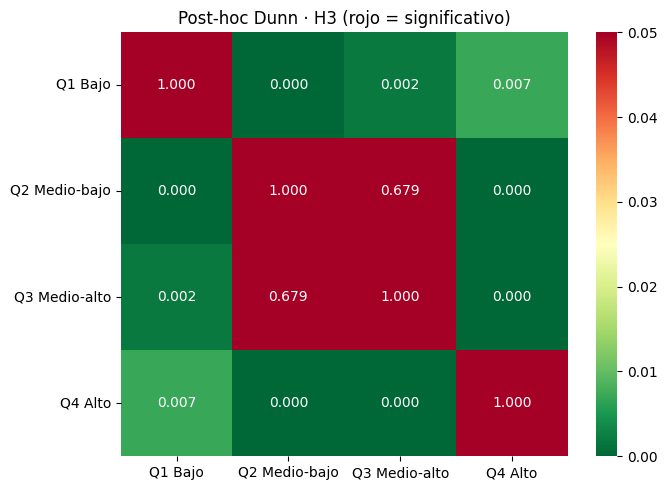

In [57]:
#pip install scikit-posthocs
from scikit_posthocs import posthoc_dunn

if p_anova < 0.05:
    dunn = posthoc_dunn(
        df_h3,
        val_col='endangerment_score',
        group_col='gdp_cuartil',
        p_adjust='bonferroni'
    )
    print("Post-hoc Dunn (p-valores ajustados con Bonferroni):")
    print(dunn.round(4))

    # Heatmap del post-hoc
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(dunn, annot=True, fmt='.3f', cmap='RdYlGn_r',
                vmin=0, vmax=0.05, ax=ax)
    ax.set_title('Post-hoc Dunn · H3 (rojo = significativo)')
    plt.tight_layout()
    plt.savefig("src/img/H3-3.png")  
    plt.show()

## Interpretación final H3

El análisis de Spearman muestra una correlación prácticamente inexistente 
(ρ = 0.071) entre el PIB per cápita y el nivel de peligro de las lenguas. 
Sin embargo, el test de Kruskal-Wallis y el post-hoc Dunn revelan que los 
países más pobres (Q1) sí presentan diferencias significativas respecto al 
resto de grupos.

Esto sugiere que el PIB no actúa como un predictor lineal del peligro 
lingüístico, sino que existe un umbral mínimo de desarrollo económico 
por debajo del cual las lenguas están más amenazadas. H3 se rechaza 
en su formulación original.

# H4: Alfabetización y extinción lingüística
Hipótesis: **Los países con mayor tasa de alfabetización tienen, de media, lenguas con menor grado de peligro: la educación puede ayudar a la preservación lingüística.**  
Evaluaremos esta hipótesis con el **t-test de Welch** comparando el `endangerment_score` medio entre dos grupos de países: los que están por encima y por debajo de la mediana de alfabetización. Usamos Welch (y no el t-test clásico) porque no asume varianzas iguales entre grupos, lo que es más seguro con datos reales. Complementaremos con el **tamaño del efecto (Cohen's d)** para no depender únicamente del p-valor.  
*Evaluación de los resultados*:
- Si el grupo de alta alfabetización tiene un score medio significativamente menor, la hipótesis se confirma → la educación actúa como factor protector.
- Si el grupo de baja alfabetización tiene menor score, el resultado sería contrario a lo esperado → la escolarización en lengua oficial podría acelerar el abandono de lenguas locales.
- Si no hay diferencia significativa (p > 0.05), la hipótesis se rechaza → la alfabetización no predice el grado de peligro.

In [44]:
print(df.columns.tolist())

['ID', 'Name_English', 'Countries', 'Degree_endangerment', 'Number_speakers', 'Description_location', 'endangerment_score', 'Countries_list', 'Region', 'Population', 'Area_sq_mi', 'Pop_density', 'Coastline', 'Migration', 'Infant_mortality', 'GDP', 'Literacy', 'Phones', 'Arable', 'Crops', 'Other', 'Climate', 'Birthrate', 'Deathrate', 'Agriculture', 'Industry', 'Service']


Filas válidas para H4: 2801
Mediana de alfabetización: 89.0%


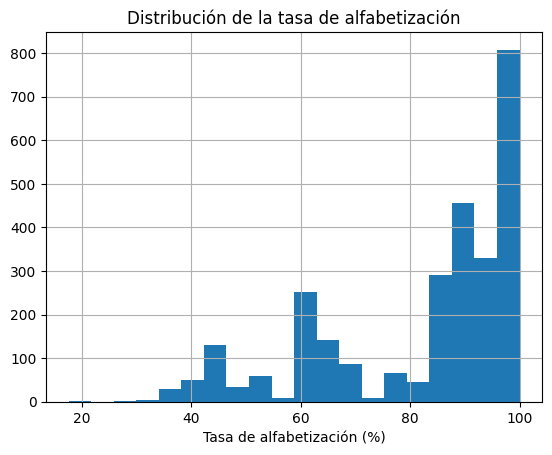

In [ ]:
# DF con columnas necesarias - nulos
df_h4 = df[['Literacy', 'endangerment_score']].dropna()

# Check numérico y conversor de decimales (, y .)
df_h4['Literacy'] = (
    df_h4['Literacy']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

print(f"Filas válidas para H4: {len(df_h4)}")
print(f"Mediana de alfabetización: {df_h4['Literacy'].median():.1f}%")
df_h4['Literacy'].hist(bins=20)
plt.xlabel('Tasa de alfabetización (%)')
plt.title('Distribución de la tasa de alfabetización')
plt.show()

In [49]:
from scipy.stats import spearmanr

df_h4 = df[['Literacy', 'endangerment_score']].dropna()

df_h4['Literacy'] = (
    df_h4['Literacy']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

corr_h4, p_valor_h4 = spearmanr(df_h4['Literacy'], df_h4['endangerment_score'])

print(f"Coeficiente de Spearman: {corr_h4:.4f}")
print(f"p-valor:                 {p_valor_h4:.4f}")

if p_valor < 0.05:
    direction = "negativa" if corr < 0 else "positiva"
    
    if abs(corr) < 0.1:
        fuerza = "prácticamente inexistente"
    elif abs(corr) < 0.3:
        fuerza = "débil"
    elif abs(corr) < 0.5:
        fuerza = "moderada"
    else:
        fuerza = "fuerte"
    
    print(f"→ Correlación {direction} (podríamos rechazar H0)")
    print(f"→ Fuerza del efecto: {fuerza} (ρ = {corr:.3f})")
else:
    print("→ No hay evidencia suficiente para rechazar H0")

Coeficiente de Spearman: 0.0707
p-valor:                 0.0002
→ Correlación positiva (podríamos rechazar H0)
→ Fuerza del efecto: prácticamente inexistente (ρ = 0.071)


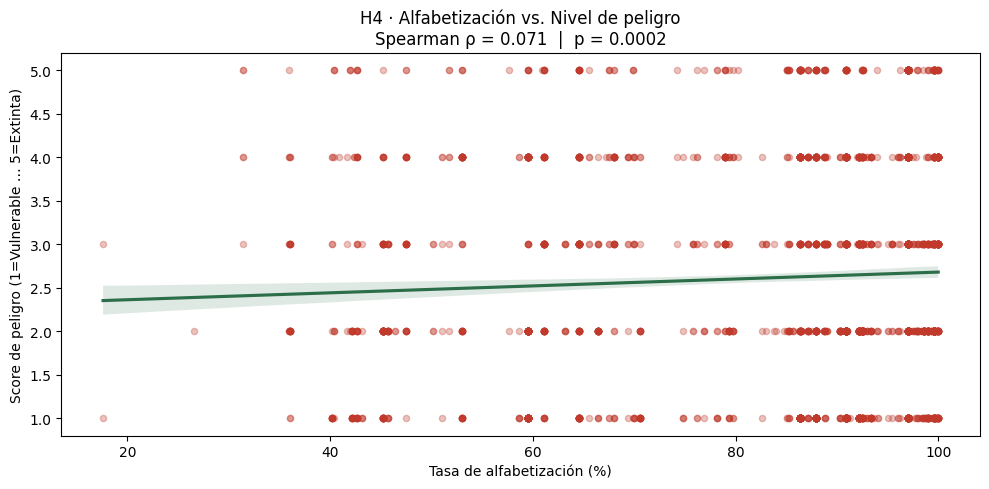

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.regplot(
    data=df_h4,
    x='Literacy',
    y='endangerment_score',
    scatter_kws={'alpha': 0.3, 's': 20, 'color': '#c0392b'},
    line_kws={'color': '#2c6e49'},
    ax=ax
)

ax.set_xlabel('Tasa de alfabetización (%)')
ax.set_ylabel('Score de peligro (1=Vulnerable … 5=Extinta)')
ax.set_title(
    f'H4 · Alfabetización vs. Nivel de peligro\nSpearman ρ = {corr_h4:.3f}  |  p = {p_valor_h4:.4f}',
    fontsize=12
)

plt.tight_layout()
plt.savefig("src/img/H4-1.png")  
plt.show()

In [54]:
from scipy.stats import kruskal, shapiro

# Dividir literacy en 4 cuartiles
df_h4['literacy_cuartil'] = pd.qcut(
    df_h4['Literacy'],
    q=4,
    labels=['Q1 Bajo', 'Q2 Medio-bajo', 'Q3 Medio-alto', 'Q4 Alto']
)

grupos = [
    df_h4[df_h4['literacy_cuartil'] == cat]['endangerment_score'].values
    for cat in ['Q1 Bajo', 'Q2 Medio-bajo', 'Q3 Medio-alto', 'Q4 Alto']
]

# Normalidad
print("Test de normalidad por grupo (Shapiro-Wilk):")
for g, nombre in zip(grupos, ['Q1', 'Q2', 'Q3', 'Q4']):
    _, p = shapiro(g[:5000])
    print(f"  {nombre}: p = {p:.4f} {'✓ Normal' if p > 0.05 else '✗ No normal → usar Kruskal'}")

# Kruskal-Wallis
stat, p_kruskal = kruskal(*grupos)
print(f"\nKruskal-Wallis: H = {stat:.3f}  |  p = {p_kruskal:.4f}")

if p_kruskal < 0.05:
    print("→ Diferencias significativas entre cuartiles de alfabetización → aplicar post-hoc")
else:
    print("→ No hay diferencias significativas entre cuartiles")

Test de normalidad por grupo (Shapiro-Wilk):
  Q1: p = 0.0000 ✗ No normal → usar Kruskal
  Q2: p = 0.0000 ✗ No normal → usar Kruskal
  Q3: p = 0.0000 ✗ No normal → usar Kruskal
  Q4: p = 0.0000 ✗ No normal → usar Kruskal

Kruskal-Wallis: H = 9.247  |  p = 0.0262
→ Diferencias significativas entre cuartiles de alfabetización → aplicar post-hoc


C:\Users\User\AppData\Local\Temp\ipykernel_13148\60638211.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


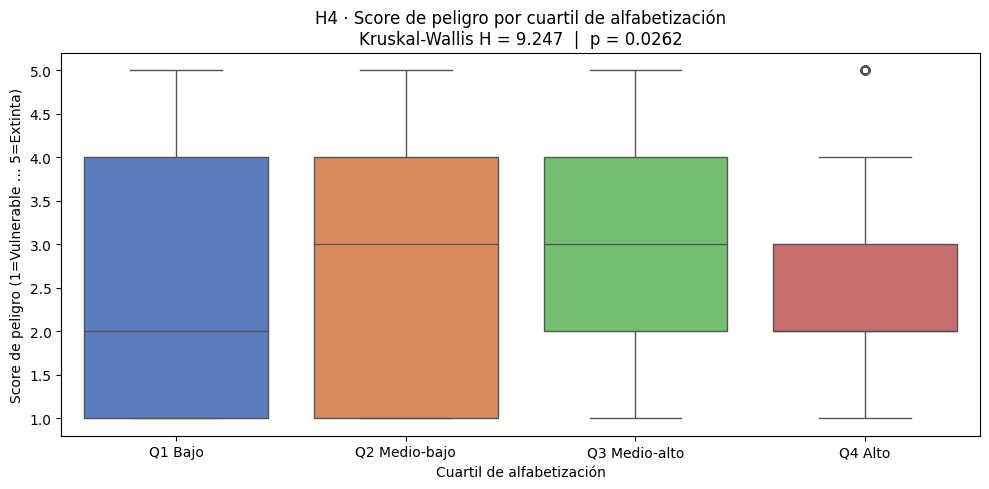

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df_h4,
    x='literacy_cuartil',
    y='endangerment_score',
    palette='muted',
    ax=ax
)

ax.set_xlabel('Cuartil de alfabetización')
ax.set_ylabel('Score de peligro (1=Vulnerable … 5=Extinta)')
ax.set_title(
    f'H4 · Score de peligro por cuartil de alfabetización\nKruskal-Wallis H = {stat:.3f}  |  p = {p_kruskal:.4f}',
    fontsize=12
)

plt.tight_layout()
plt.savefig("src/img/H4-2.png")  
plt.show()

Post-hoc Dunn (p-valores ajustados con Bonferroni):
               Q1 Bajo  Q2 Medio-bajo  Q3 Medio-alto  Q4 Alto
Q1 Bajo         1.0000         0.4537         0.0145   0.7434
Q2 Medio-bajo   0.4537         1.0000         1.0000   1.0000
Q3 Medio-alto   0.0145         1.0000         1.0000   1.0000
Q4 Alto         0.7434         1.0000         1.0000   1.0000


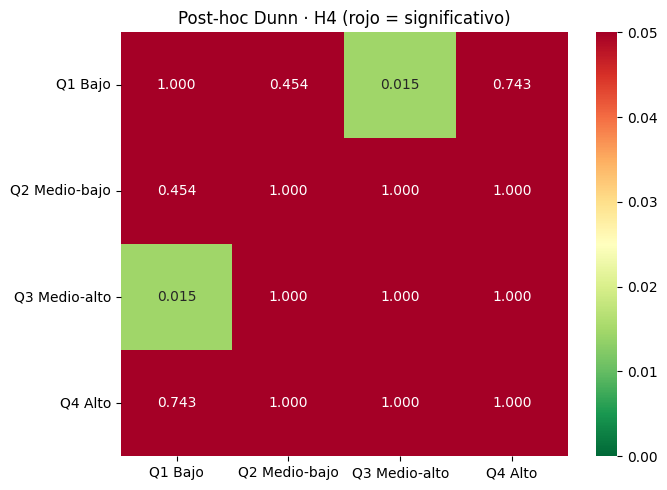

In [60]:
from scikit_posthocs import posthoc_dunn

if p_kruskal < 0.05:
    dunn = posthoc_dunn(
        df_h4,
        val_col='endangerment_score',
        group_col='literacy_cuartil',
        p_adjust='bonferroni'
    )
    print("Post-hoc Dunn (p-valores ajustados con Bonferroni):")
    print(dunn.round(4))

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(dunn, annot=True, fmt='.3f', cmap='RdYlGn_r',
                vmin=0, vmax=0.05, ax=ax)
    ax.set_title('Post-hoc Dunn · H4 (rojo = significativo)')
    plt.tight_layout()
    plt.savefig("src/img/H4-3.png")  
    plt.show()

## Interpretación final H4

El análisis de Spearman muestra una correlación prácticamente inexistente
(ρ = 0.071) entre la tasa de alfabetización y el nivel de peligro de las
lenguas. El post-hoc Dunn únicamente detecta diferencias significativas
entre Q1 (baja alfabetización) y Q3 (media-alta alfabetización), sin que
exista una tendencia progresiva clara entre los cuatro grupos.

La alfabetización por sí sola no predice de forma consistente el grado
de peligro de las lenguas. H4 se rechaza.